In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("world_top_restaurants_dataset_cleaned.csv")

target = "rating"
exclude_cols = [target, "restaurant_name", "chef", "signature_dish"]

X = df.drop(columns=[c for c in exclude_cols if c in df.columns])
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape


((40, 11), (10, 11))

In [3]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)


In [4]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

models = {
    "Baseline_DummyMean": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

cv_results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    scores = cross_validate(pipe, X_train, y_train, cv=5, scoring=scoring)
    cv_results[name] = {
        "CV_RMSE_mean": -scores["test_rmse"].mean(),
        "CV_RMSE_std": scores["test_rmse"].std(),
        "CV_MAE_mean": -scores["test_mae"].mean(),
        "CV_R2_mean": scores["test_r2"].mean()
    }

cv_df = pd.DataFrame(cv_results).T.sort_values("CV_RMSE_mean")
cv_df


,CV_RMSE_mean,CV_RMSE_std,CV_MAE_mean,CV_R2_mean
RandomForest,0.075876,0.010720,0.059500,0.463545
GradientBoosting,0.079580,0.014240,0.063258,0.383491
Ridge,0.088327,0.024761,0.064670,0.202439
LinearRegression,0.105301,0.020031,0.080076,-0.062632
Baseline_DummyMean,0.110624,0.011721,0.091250,-0.075682


In [5]:
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 3, 5, 10],
    "model__min_samples_split": [2, 4, 6],
    "model__min_samples_leaf": [1, 2, 3]
}

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV RMSE:", -rf_grid.best_score_)


Best RF params: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best RF CV RMSE: 0.0758629005679772


In [6]:
gb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4],
    "model__subsample": [1.0, 0.8]
}

gb_grid = GridSearchCV(
    gb_pipe,
    param_grid=gb_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best GB params:", gb_grid.best_params_)
print("Best GB CV RMSE:", -gb_grid.best_score_)


Best GB params: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best GB CV RMSE: 0.07631065954450911


In [7]:
def eval_on_test(fitted_model, X_test, y_test, label="Model"):
    preds = fitted_model.predict(X_test)
    rmse = mean_squared_error(y_test, preds, squared=False)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{label} Test RMSE: {rmse:.4f}")
    print(f"{label} Test MAE : {mae:.4f}")
    print(f"{label} Test R^2 : {r2:.4f}")
    return preds, {"rmse": rmse, "mae": mae, "r2": r2}

# Evaluate both tuned models
rf_preds, rf_metrics = eval_on_test(rf_grid.best_estimator_, X_test, y_test, "Tuned RandomForest")
gb_preds, gb_metrics = eval_on_test(gb_grid.best_estimator_, X_test, y_test, "Tuned GradientBoosting")

best_model = rf_grid.best_estimator_ if rf_metrics["rmse"] <= gb_metrics["rmse"] else gb_grid.best_estimator_
print("\nSelected final model:", type(best_model.named_steps["model"]).__name__)


Tuned RandomForest Test RMSE: 0.0942
Tuned RandomForest Test MAE : 0.0735
Tuned RandomForest Test R^2 : -0.0560
Tuned GradientBoosting Test RMSE: 0.0891
Tuned GradientBoosting Test MAE : 0.0743
Tuned GradientBoosting Test R^2 : 0.0550

Selected final model: GradientBoostingRegressor


C:\Users\Muhammad\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\Muhammad\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


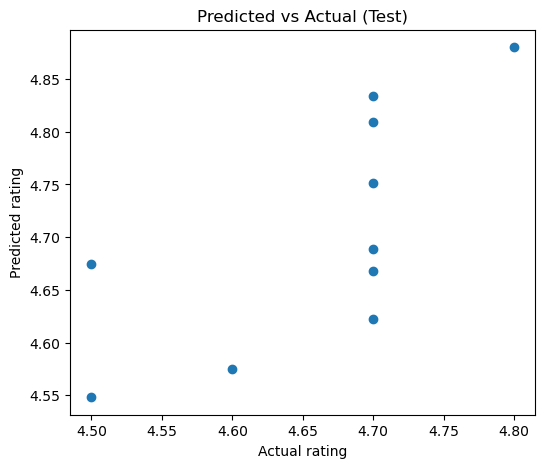

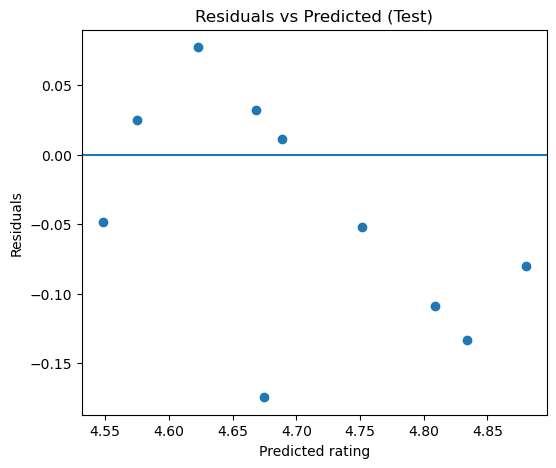

In [8]:
best_preds = best_model.predict(X_test)
residuals = y_test - best_preds

plt.figure(figsize=(6,5))
plt.scatter(y_test, best_preds)
plt.xlabel("Actual rating")
plt.ylabel("Predicted rating")
plt.title("Predicted vs Actual (Test)")
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(best_preds, residuals)
plt.axhline(0)
plt.xlabel("Predicted rating")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Test)")
plt.show()


,feature,importance
1,average_price_usd,0.373210
2,established_year,0.116347
0,michelin_stars,0.112083
90,star_category_Three Stars,0.102766
3,seating_capacity,0.061963
4,years_operating,0.056447
65,cuisine_type_Contemporary Peruvian,0.026987
45,country_Russia,0.022103
44,country_Peru,0.021373
36,country_China,0.017968


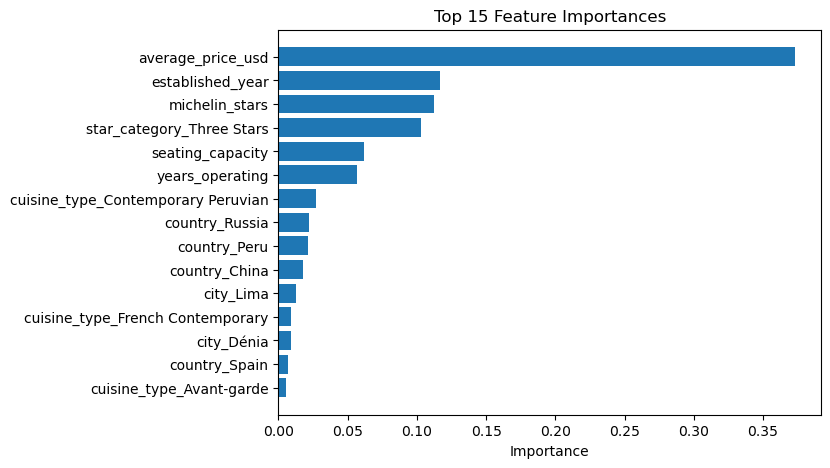

In [9]:
final_est = best_model.named_steps["model"]
if hasattr(final_est, "feature_importances_"):
    ohe = best_model.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
    cat_names = ohe.get_feature_names_out(categorical_features)
    feature_names = np.array(numeric_features + list(cat_names))

    importances = final_est.feature_importances_
    fi = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

    display(fi.head(15))

    plt.figure(figsize=(7,5))
    plt.barh(fi.head(15)["feature"][::-1], fi.head(15)["importance"][::-1])
    plt.xlabel("Importance")
    plt.title("Top 15 Feature Importances")
    plt.show()
else:
    print("Final model does not support feature_importances_.")
